In [8]:
import pandas as pd

golden = pd.read_csv("../data/golden_set.csv")

# Keep only tweets you've labeled
golden = golden[golden["intent"].notna() & (golden["intent"] != "")]

print("Labeled tweets:", len(golden))
golden[["text", "intent"]].head()

Labeled tweets: 52


,text,intent
0,@SpotifyCares Best response ever! Me @ the use...,General Inquiry
1,@SpotifyCares Spotify Student + Hulu renews to...,Premium Billing
2,@SpotifyCares I just dumped the whole thing. I...,Playback Issues
3,"@SpotifyCares my band's ""related artists"" sect...",Playback Issues
4,"@SpotifyCares Uh no....that""s not an answer. G...",General Inquiry


In [9]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1000
)

X = vectorizer.fit_transform(golden["text"])
y = golden["intent"]

print("Feature matrix:", X.shape)

Feature matrix: (52, 324)


In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape[0])
print("Test:", X_test.shape[0])

Train: 41
Test: 11


In [11]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=500)

model.fit(X_train, y_train)

print("Model trained successfully!")


Model trained successfully!


In [12]:
from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print(f"Accuracy: {accuracy*100:.2f}%")

print(classification_report(y_test, predictions))

Accuracy: 36.36%
                 precision    recall  f1-score   support

General Inquiry       0.40      0.80      0.53         5
Playback Issues       0.00      0.00      0.00         4
Premium Billing       0.00      0.00      0.00         2

       accuracy                           0.36        11
      macro avg       0.13      0.27      0.18        11
   weighted avg       0.18      0.36      0.24        11



/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [13]:
results = pd.DataFrame({
    "Tweet": golden.iloc[y_test.index]["text"].values,
    "Actual": y_test.values,
    "Predicted": predictions
})

mistakes = results[results["Actual"] != results["Predicted"]]

mistakes

,Tweet,Actual,Predicted
0,@SpotifyCares I have tried both ways.,General Inquiry,Playback Issues
1,@SpotifyCares I'm on macOs 10.12.5 and Chrome ...,Playback Issues,General Inquiry
5,"@SpotifyCares 1st in playlist playing song 28,...",Playback Issues,General Inquiry
6,@SpotifyCares I have a US premium account.,Premium Billing,General Inquiry
7,@218539 @SpotifyCares Problem network je ni 😶,Playback Issues,General Inquiry
8,@SpotifyCares Spotify Student + Hulu renews to...,Premium Billing,General Inquiry
10,@SpotifyCares any way to get play/pause button...,Playback Issues,General Inquiry


In [14]:
import os
import pickle

os.makedirs("../results", exist_ok=True)

pickle.dump(model, open("../results/intent_model.pkl", "wb"))
pickle.dump(vectorizer, open("../results/vectorizer.pkl", "wb"))

print("Saved model and vectorizer!")

Saved model and vectorizer!


In [15]:
from sklearn.metrics import accuracy_score, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print()
print(classification_report(y_test, y_pred))

Accuracy: 0.36363636363636365

                 precision    recall  f1-score   support

General Inquiry       0.40      0.80      0.53         5
Playback Issues       0.00      0.00      0.00         4
Premium Billing       0.00      0.00      0.00         2

       accuracy                           0.36        11
      macro avg       0.13      0.27      0.18        11
   weighted avg       0.18      0.36      0.24        11



/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/mokaanjali/Desktop/hiver-ai-support-agent/venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

Matplotlib is building the font cache; this may take a moment.


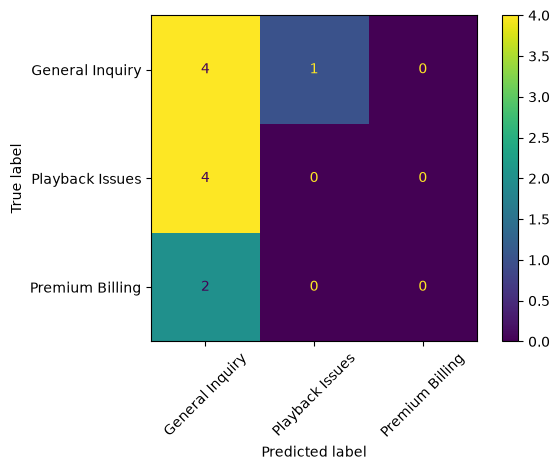

In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    model,
    X_test,
    y_test,
    xticks_rotation=45
)

plt.tight_layout()
plt.savefig("../results/confusion_matrix.png", dpi=300)
plt.show()

In [19]:
import joblib

joblib.dump(model, "../results/intent_model.pkl")
print("Model saved!")

Model saved!
